# 🔍 Minimal Debug Deployment Notebook

A minimal notebook for debugging policy deployment:
1. Load policy
2. Get observation from **robot** OR **dataset**
3. Predict **full action chunk**
4. Visualize the chunk before sending
5. (Optional) Send actions **one step at a time** to robot
6. Repeat for next chunk

**Modes:**
- `USE_DATASET = True`: Load observations from dataset (no robot needed)
- `USE_DATASET = False`: Get live observations from robot

## 1. Configuration

In [ ]:
import pathlib

# ============================================================
# MODE: Choose data source
# ============================================================
USE_DATASET = True  # True = load from dataset, False = live robot

# ============================================================
# Policy checkpoint
# ============================================================
# TODO: Set your checkpoint path
CHECKPOINT_DIR = pathlib.Path("/data/models/your_checkpoint_here")

# ============================================================
# Dataset settings (only used if USE_DATASET = True)
# ============================================================
DATASET_DIR = pathlib.Path("/data/lerobot/your_dataset_here")
EPISODE_INDEX = 0  # Which episode to use
START_FRAME = 0    # Starting frame within episode

# ============================================================
# Robot settings (only used if USE_DATASET = False)
# ============================================================
SERVER_ENDPOINT = "localhost:50051"

# ============================================================
# Common settings
# ============================================================
DEVICE = "cpu"  # or "cpu"
ACTION_HZ = 10.0  # Frequency for sending actions

print(f"Mode: {'DATASET' if USE_DATASET else 'ROBOT'}")
print(f"Checkpoint: {CHECKPOINT_DIR}")
if USE_DATASET:
    print(f"Dataset: {DATASET_DIR}")
    print(f"Episode: {EPISODE_INDEX}, Start frame: {START_FRAME}")
else:
    print(f"Server: {SERVER_ENDPOINT}")
print(f"Device: {DEVICE}")

Mode: DATASET
Checkpoint: /home/adriankobras/Documents/Code/hackathon-example-policies/data/models/putstapinbox_ditf_1obs
Dataset: /home/adriankobras/Documents/Code/hackathon-example-policies/data/put_stapler_in_box/put_stapler_in_box
Episode: 0, Start frame: 0
Device: cpu


## 2. Load Policy

In [2]:
from example_policies.robot_deploy.deploy_core.policy_manager import PolicyManager

# Load policy bundle (includes policy, config, translator)
policy_bundle = PolicyManager.load_single(CHECKPOINT_DIR, DEVICE)

policy = policy_bundle.policy
cfg = policy_bundle.config
translator = policy_bundle.translator

# Print key config values
n_obs_steps = getattr(policy.config, 'n_obs_steps', 1)
n_action_steps = getattr(policy.config, 'n_action_steps', 16)
action_mode = translator.action_mode

print(f"\n✅ Policy loaded!")
print(f"  n_obs_steps: {n_obs_steps}")
print(f"  n_action_steps: {n_action_steps}")
print(f"  action_mode: {action_mode}")
print(f"  device: {cfg.device}")

/home/adriankobras/Documents/Code/hackathon-example-policies/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading checkpoint: putstapinbox_ditf_1obs
Checkpoint path /home/adriankobras/Documents/Code/hackathon-example-policies/data/models/putstapinbox_ditf_1obs does not contain config.json, extending path.


Number of flow params: 42.02M
Loading weights from local directory
  Termination signal support: True

✅ Policy loaded!
  n_obs_steps: 1
  n_action_steps: 8
  action_mode: ActionMode.DELTA_TCP
  device: cpu


## 3. Load Dataset (if USE_DATASET = True)

Skip this cell if using live robot.

In [ ]:
if USE_DATASET:
    import os
    import json
    import torch
    from lerobot.datasets.lerobot_dataset import LeRobotDataset
    
    # Prevent trying to download from HuggingFace Hub
    os.environ["HF_HUB_OFFLINE"] = "1"
    
    # Load dataset
    print(f"Loading dataset from {DATASET_DIR}...")
    dataset = LeRobotDataset(
        repo_id=str(DATASET_DIR),
        root=DATASET_DIR,
        video_backend="pyav",  # Use pyav instead of torchcodec
    )
    print(f"✅ Dataset loaded: {len(dataset)} frames")
    
    # Get episode info from dataset metadata
    # LeRobot v3.0 uses HuggingFace Dataset, v2.1 uses dict
    episodes_data = dataset.meta.episodes
    total_episodes = dataset.meta.total_episodes
    print(f"Total episodes: {total_episodes}")
    
    # Handle both v3.0 (Dataset) and v2.1 (dict) formats
    episode_info = episodes_data[EPISODE_INDEX]
    episode_length = episode_info["length"]
    episode_start_idx = sum(episodes_data[i]["length"] for i in range(EPISODE_INDEX))
    
    print(f"✅ Episode {EPISODE_INDEX}: {episode_length} frames")
    print(f"   Dataset indices: {episode_start_idx} to {episode_start_idx + episode_length - 1}")
    
    # Current frame pointer for iteration
    current_dataset_frame = START_FRAME
    
    def get_observation_from_dataset(frame_idx):
        """Get observation dict from dataset at given frame index."""
        global current_dataset_frame
        
        dataset_idx = episode_start_idx + frame_idx
        if dataset_idx >= episode_start_idx + episode_length:
            print(f"⚠️ Frame {frame_idx} exceeds episode length {episode_length}")
            return None
        
        # Get sample from dataset
        sample = dataset[dataset_idx]
        
        # Convert to observation format expected by policy
        observation = {}
        for key, value in sample.items():
            if key.startswith('observation.'):
                if torch.is_tensor(value):
                    # Add batch dimension
                    observation[key] = value.unsqueeze(0).to(DEVICE)
                else:
                    observation[key] = value
        
        current_dataset_frame = frame_idx
        return observation
    
    print(f"\n✅ Dataset ready! Use get_observation_from_dataset(frame_idx)")
else:
    print("Skipping dataset loading (USE_DATASET = False)")

Loading dataset from /home/adriankobras/Documents/Code/hackathon-example-policies/data/put_stapler_in_box/put_stapler_in_box...
✅ Dataset loaded: 8588 frames
✅ Episode 0: 247 frames
   Dataset indices: 0 to 246

✅ Dataset ready! Use get_observation_from_dataset(frame_idx)


## 3. Setup Visualization

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output

from example_policies.utils.action_order import (
    ActionMode,
    DUAL_ABS_LEFT_POS_IDXS,
    DUAL_ABS_RIGHT_POS_IDXS,
    DUAL_DELTA_LEFT_POS_IDXS,
    DUAL_DELTA_RIGHT_POS_IDXS,
)


def show_observation_images(observation):
    """Display all camera images from the observation."""
    image_keys = sorted([k for k in observation.keys() if k.startswith('observation.image')])
    
    if not image_keys:
        print("No images in observation")
        return
    
    n = len(image_keys)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 3))
    if n == 1:
        axes = [axes]
    
    for ax, key in zip(axes, image_keys):
        img = observation[key].squeeze(0).cpu()
        # Handle 4D tensor (n_obs_steps, C, H, W) - take last frame
        while img.dim() > 3:
            img = img[-1]  # Take last observation step
        # CHW -> HWC
        if img.shape[0] in [1, 3]:
            img = img.permute(1, 2, 0)
        img = img.numpy()
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        ax.imshow(img)
        ax.set_title(key.split('.')[-1])
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


def show_state(observation):
    """Print state vector info."""
    if 'observation.state' not in observation:
        print("No state in observation")
        return
    
    state = observation['observation.state'].squeeze(0).cpu()
    # Handle multi-step observations
    if state.dim() > 1:
        state = state[-1]  # Take last observation step
    state = state.numpy()
    print(f"\n📊 State (dim={len(state)}):")
    print(f"   {state}")


def visualize_action_chunk(action_chunk, action_mode, observation=None):
    """
    Visualize the full action chunk as 3D trajectories.
    
    Args:
        action_chunk: Tensor (n_action_steps, action_dim)
        action_mode: ActionMode enum
        observation: Current observation (needed for delta actions)
    """
    chunk = action_chunk.detach().cpu().numpy()
    T = chunk.shape[0]
    
    is_delta = action_mode == ActionMode.DELTA_TCP
    
    if is_delta:
        # For delta actions, integrate from current state
        if observation is not None and 'observation.state' in observation:
            state = observation['observation.state'].squeeze(0).cpu()
            if state.dim() > 1:
                state = state[-1]
            state = state.numpy()
            # Assuming state order: left_pos(3), left_quat(4), right_pos(3), right_quat(4), ...
            left_init = state[:3]
            right_init = state[7:10]
        else:
            left_init = np.zeros(3)
            right_init = np.zeros(3)
        
        # Integrate deltas
        left_traj = [left_init.copy()]
        right_traj = [right_init.copy()]
        
        for t in range(T):
            left_traj.append(left_traj[-1] + chunk[t, DUAL_DELTA_LEFT_POS_IDXS])
            right_traj.append(right_traj[-1] + chunk[t, DUAL_DELTA_RIGHT_POS_IDXS])
        
        left_traj = np.array(left_traj)
        right_traj = np.array(right_traj)
    else:
        # Absolute actions
        left_traj = chunk[:, DUAL_ABS_LEFT_POS_IDXS]
        right_traj = chunk[:, DUAL_ABS_RIGHT_POS_IDXS]
    
    # Plot
    fig = plt.figure(figsize=(12, 5))
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(left_traj[:, 0], left_traj[:, 1], left_traj[:, 2], 'b-o', markersize=3)
    ax1.scatter(*left_traj[0], c='green', s=100, marker='^', label='Start')
    ax1.scatter(*left_traj[-1], c='red', s=100, marker='s', label='End')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.set_title('Left Arm')
    ax1.legend()
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot(right_traj[:, 0], right_traj[:, 1], right_traj[:, 2], 'r-o', markersize=3)
    ax2.scatter(*right_traj[0], c='green', s=100, marker='^', label='Start')
    ax2.scatter(*right_traj[-1], c='red', s=100, marker='s', label='End')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    ax2.set_title('Right Arm')
    ax2.legend()
    
    plt.suptitle(f'Action Chunk ({T} steps, mode={action_mode.value})')
    plt.tight_layout()
    plt.show()
    
    # Print stats
    print(f"\n📈 Chunk stats:")
    print(f"   Left travel:  {np.linalg.norm(left_traj[-1] - left_traj[0]):.4f} m")
    print(f"   Right travel: {np.linalg.norm(right_traj[-1] - right_traj[0]):.4f} m")
    print(f"   Action range: [{chunk.min():.4f}, {chunk.max():.4f}]")


print("✅ Visualization functions ready!")

✅ Visualization functions ready!


## 4. Connect to Robot (if USE_DATASET = False)

Skip this cell if using dataset mode.

In [12]:
import psutil
import shutil

def check_system_health():
    """Check and display system health metrics."""
    print("=" * 60)
    print("🖥️  SYSTEM HEALTH CHECK")
    print("=" * 60)
    
    # CPU
    cpu_percent = psutil.cpu_percent(interval=0.5)
    cpu_count = psutil.cpu_count()
    cpu_freq = psutil.cpu_freq()
    print(f"\n🔲 CPU:")
    print(f"   Usage: {cpu_percent:.1f}%")
    print(f"   Cores: {cpu_count}")
    if cpu_freq:
        print(f"   Frequency: {cpu_freq.current:.0f} MHz")
    
    # Memory
    mem = psutil.virtual_memory()
    print(f"\n💾 Memory:")
    print(f"   Total: {mem.total / (1024**3):.1f} GB")
    print(f"   Used:  {mem.used / (1024**3):.1f} GB ({mem.percent:.1f}%)")
    print(f"   Available: {mem.available / (1024**3):.1f} GB")
    
    # Disk
    disk = shutil.disk_usage("/")
    print(f"\n💿 Disk (/):")
    print(f"   Total: {disk.total / (1024**3):.1f} GB")
    print(f"   Used:  {disk.used / (1024**3):.1f} GB ({100 * disk.used / disk.total:.1f}%)")
    print(f"   Free:  {disk.free / (1024**3):.1f} GB")
    
    # GPU (if available)
    print(f"\n🎮 GPU:")
    try:
        import torch
        if torch.cuda.is_available():
            for i in range(torch.cuda.device_count()):
                props = torch.cuda.get_device_properties(i)
                mem_allocated = torch.cuda.memory_allocated(i) / (1024**3)
                mem_reserved = torch.cuda.memory_reserved(i) / (1024**3)
                mem_total = props.total_memory / (1024**3)
                
                print(f"   GPU {i}: {props.name}")
                print(f"      Memory: {mem_allocated:.2f} GB allocated / {mem_total:.1f} GB total")
                print(f"      Reserved: {mem_reserved:.2f} GB")
                
                # Try to get utilization via nvidia-smi
                try:
                    import subprocess
                    result = subprocess.run(
                        ['nvidia-smi', '--query-gpu=utilization.gpu', '--format=csv,noheader,nounits', f'--id={i}'],
                        capture_output=True, text=True, timeout=2
                    )
                    if result.returncode == 0:
                        gpu_util = result.stdout.strip()
                        print(f"      Utilization: {gpu_util}%")
                except:
                    pass
        else:
            print("   No CUDA GPU available")
    except ImportError:
        print("   PyTorch not available for GPU check")
    
    # Process info
    process = psutil.Process()
    print(f"\n📊 This Process:")
    print(f"   Memory: {process.memory_info().rss / (1024**3):.2f} GB")
    print(f"   CPU: {process.cpu_percent(interval=0.1):.1f}%")
    print(f"   Threads: {process.num_threads()}")
    
    # Health warnings
    print(f"\n⚠️  Warnings:")
    warnings = []
    if cpu_percent > 80:
        warnings.append(f"   ⚠️ High CPU usage: {cpu_percent:.1f}%")
    if mem.percent > 85:
        warnings.append(f"   ⚠️ High memory usage: {mem.percent:.1f}%")
    if 100 * disk.used / disk.total > 90:
        warnings.append(f"   ⚠️ Low disk space: {disk.free / (1024**3):.1f} GB free")
    
    if warnings:
        for w in warnings:
            print(w)
    else:
        print("   ✅ All systems nominal")
    
    print("=" * 60)

# Run system health check
check_system_health()

# Robot connection
robot_interface = None

if not USE_DATASET:
    from example_policies.robot_deploy.robot_io.connection import RobotConnection
    from example_policies.robot_deploy.robot_io.robot_interface import RobotInterface
    from example_policies.robot_deploy.robot_io.robot_client import RobotClient

    # Create persistent connection (will be used in subsequent cells)
    robot_connection = RobotConnection(SERVER_ENDPOINT)
    stub = robot_connection.__enter__()
    robot_interface = RobotInterface(stub, cfg)

    print(f"\n✅ Connected to robot at {SERVER_ENDPOINT}")
else:
    print("\nSkipping robot connection (USE_DATASET = True)")

🖥️  SYSTEM HEALTH CHECK

🔲 CPU:
   Usage: 7.8%
   Cores: 16
   Frequency: 1483 MHz

💾 Memory:
   Total: 27.1 GB
   Used:  10.1 GB (37.4%)
   Available: 16.9 GB

💿 Disk (/):
   Total: 936.8 GB
   Used:  111.4 GB (11.9%)
   Free:  777.7 GB

🎮 GPU:
   No CUDA GPU available

📊 This Process:
   Memory: 1.25 GB
   CPU: 0.0%
   Threads: 69

⚠️  Warnings:
   ✅ All systems nominal

Skipping robot connection (USE_DATASET = True)


## 5. Move Robot Home (if using robot)

Skip if using dataset mode.

In [ ]:
if robot_interface is not None:
    print("Moving robot to home position...")
    robot_interface.move_home()
    print("✅ Robot at home position")
else:
    print("Skipping (no robot connection)")

## 6. Get Observation & Visualize

Get observation from dataset or robot and see what the policy sees.

/home/adriankobras/Documents/Code/hackathon-example-policies/.venv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


📂 Observation from dataset frame 0
✅ Observation received!

Keys: ['observation.images.rgb_static', 'observation.images.rgb_left', 'observation.images.rgb_right', 'observation.state']


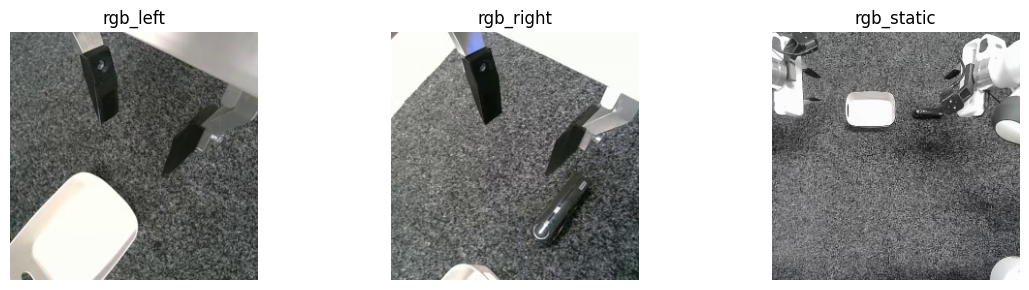


📊 State (dim=32):
   [-0.25776678  0.78269416  0.3130698   0.00472514  0.98165977  0.07457691
  0.17538534  0.21118115  0.79516655  0.31110162 -0.01047816 -0.9818415
 -0.06270896  0.1787319   0.0349281   0.0349281   0.03492416  0.03492416
 -0.26018193  0.78381056  0.3148524   0.00293408  0.98153794  0.0770489
  0.17503743  0.21170054  0.79526067  0.30198383 -0.01505966 -0.9844436
 -0.05846536  0.16500232]


In [5]:
# Get observation from appropriate source
if USE_DATASET:
    observation = get_observation_from_dataset(current_dataset_frame)
    print(f"📂 Observation from dataset frame {current_dataset_frame}")
else:
    observation = robot_interface.get_observation(DEVICE)
    print(f"🤖 Observation from robot")

if observation:
    print(f"✅ Observation received!")
    print(f"\nKeys: {list(observation.keys())}")
    
    # Show images
    show_observation_images(observation)
    
    # Show state
    show_state(observation)
else:
    print("❌ No observation received!")

## 7. Predict Full Action Chunk & Visualize

This predicts the **entire action chunk** and visualizes it before sending.

📂 Using dataset frame 0

🔍 Debug: Raw observation shapes:
   observation.images.rgb_static: torch.Size([1, 1, 3, 256, 256])
   observation.images.rgb_left: torch.Size([1, 1, 3, 256, 256])
   observation.images.rgb_right: torch.Size([1, 1, 3, 256, 256])
   observation.state: torch.Size([1, 32])

🔍 Debug: Model expects n_obs_steps = 1

🎲 Generating 20 action chunk samples...
✅ Generated 20 action chunks!
   Shape: torch.Size([20, 8, 15])


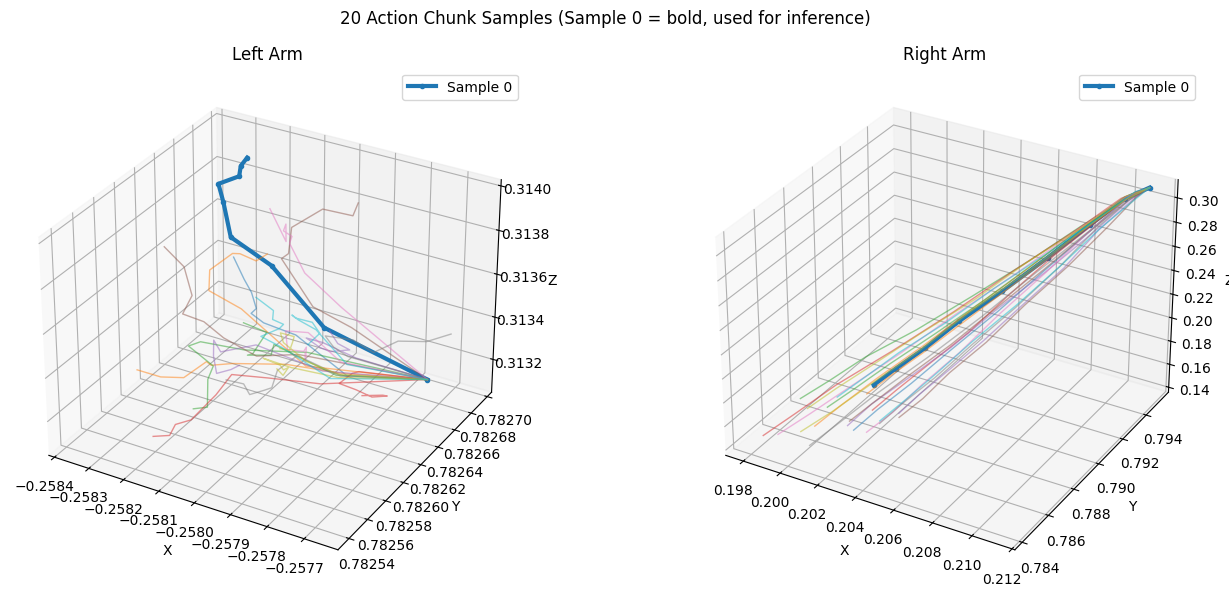


✅ Using Sample 0 for inference
   Shape: torch.Size([8, 15])
   Action mode: ActionMode.DELTA_TCP

📊 Sample statistics:
   Mean action std across samples: 0.000572
   Max action std across samples:  0.004913

📊 Visualization only (no robot connected).


In [11]:
# Ensure robot_interface is defined (may not exist if robot cell wasn't run)
if 'robot_interface' not in dir():
    robot_interface = None

# ============================================================
# Number of action chunk samples to generate (use first one for inference)
# ============================================================
NUM_SAMPLES = 20  # Generate this many samples, visualize all, use first

# Reset the policy's action queue to force a new prediction
policy.reset()

# Get fresh observation
if USE_DATASET:
    observation = get_observation_from_dataset(current_dataset_frame)
    print(f"📂 Using dataset frame {current_dataset_frame}")
else:
    observation = robot_interface.get_observation(DEVICE)
    print(f"🤖 Using live robot observation")

if not observation:
    raise RuntimeError("Failed to get observation")

# Debug: Show raw observation shapes
print(f"\n🔍 Debug: Raw observation shapes:")
for k, v in observation.items():
    if torch.is_tensor(v):
        print(f"   {k}: {v.shape}")

expected_n_obs_steps = policy.config.n_obs_steps
print(f"\n🔍 Debug: Model expects n_obs_steps = {expected_n_obs_steps}")

# Prepare observation for policy
obs_normalized = policy.normalize_inputs(observation)
obs_normalized = dict(obs_normalized)  # shallow copy

# Fix state shape: dataset gives (B, state_dim), model expects (B, n_obs_steps, state_dim)
state = obs_normalized["observation.state"]

if state.dim() == 2:
    # Shape is (B, state_dim) - missing n_obs_steps dimension
    state = state.unsqueeze(1)  # (B, 1, state_dim)
    if expected_n_obs_steps > 1:
        state = state.expand(-1, expected_n_obs_steps, -1)
    obs_normalized["observation.state"] = state

elif state.dim() == 3:
    actual_n_obs_steps = state.shape[1]
    if actual_n_obs_steps != expected_n_obs_steps:
        obs_normalized["observation.state"] = state[:, -expected_n_obs_steps:, ...]

# Fix image shapes similarly
if policy.config.image_features:
    for key in policy.config.image_features:
        img = obs_normalized[key]
        if img.dim() == 4:
            img = img.unsqueeze(1)  # (B, 1, C, H, W)
        if img.dim() == 5 and img.shape[1] > expected_n_obs_steps:
            img = img[:, -expected_n_obs_steps:, ...]
        obs_normalized[key] = img

# Stack images - (B, n_obs_steps, n_cameras, C, H, W)
if policy.config.image_features:
    image_tensors = [obs_normalized[key] for key in policy.config.image_features]
    obs_normalized["observation.images"] = torch.stack(image_tensors, dim=2)

# ============================================================
# Generate multiple samples
# ============================================================
print(f"\n🎲 Generating {NUM_SAMPLES} action chunk samples...")

with torch.inference_mode():
    # Prepare conditioning (this encodes images + state)
    global_cond = policy.dit_flow._prepare_global_conditioning(obs_normalized)
    
    # Expand conditioning for multiple samples
    # global_cond is (1, cond_dim), expand to (NUM_SAMPLES, cond_dim)
    global_cond_expanded = global_cond.expand(NUM_SAMPLES, -1)
    
    # Sample multiple action trajectories
    actions_batch = policy.dit_flow.conditional_sample(
        batch_size=NUM_SAMPLES,
        global_cond=global_cond,  # Will be expanded internally
    )
    
    # Extract n_action_steps (same logic as generate_actions)
    start = expected_n_obs_steps - 1
    end = start + policy.config.n_action_steps
    actions_batch = actions_batch[:, start:end]  # (NUM_SAMPLES, n_action_steps, action_dim)
    
    # Unnormalize all samples
    from example_policies.policies.models.dit_flow.modeling_dit_flow import ACTION
    actions_batch = policy.unnormalize_outputs({ACTION: actions_batch})[ACTION]

print(f"✅ Generated {NUM_SAMPLES} action chunks!")
print(f"   Shape: {actions_batch.shape}")

# ============================================================
# Visualize all samples (first one in bold/different color)
# ============================================================
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, NUM_SAMPLES))

for i in range(NUM_SAMPLES):
    chunk = actions_batch[i].detach().cpu().numpy()
    
    is_delta = action_mode == ActionMode.DELTA_TCP
    
    if is_delta:
        if observation is not None and 'observation.state' in observation:
            state_np = observation['observation.state'].squeeze(0).cpu()
            if state_np.dim() > 1:
                state_np = state_np[-1]
            state_np = state_np.numpy()
            left_init = state_np[:3]
            right_init = state_np[7:10]
        else:
            left_init = np.zeros(3)
            right_init = np.zeros(3)
        
        left_traj = [left_init.copy()]
        right_traj = [right_init.copy()]
        for t in range(chunk.shape[0]):
            left_traj.append(left_traj[-1] + chunk[t, DUAL_DELTA_LEFT_POS_IDXS])
            right_traj.append(right_traj[-1] + chunk[t, DUAL_DELTA_RIGHT_POS_IDXS])
        left_traj = np.array(left_traj)
        right_traj = np.array(right_traj)
    else:
        left_traj = chunk[:, DUAL_ABS_LEFT_POS_IDXS]
        right_traj = chunk[:, DUAL_ABS_RIGHT_POS_IDXS]
    
    # First sample gets thicker line and markers
    lw = 3 if i == 0 else 1
    alpha = 1.0 if i == 0 else 0.5
    label = f"Sample {i}" if i == 0 else None
    
    ax1.plot(left_traj[:, 0], left_traj[:, 1], left_traj[:, 2], 
             '-o' if i == 0 else '-', color=colors[i], linewidth=lw, 
             markersize=3 if i == 0 else 0, alpha=alpha, label=label)
    ax2.plot(right_traj[:, 0], right_traj[:, 1], right_traj[:, 2], 
             '-o' if i == 0 else '-', color=colors[i], linewidth=lw,
             markersize=3 if i == 0 else 0, alpha=alpha, label=label)

ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title('Left Arm')
ax1.legend()

ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_title('Right Arm')
ax2.legend()

plt.suptitle(f'{NUM_SAMPLES} Action Chunk Samples (Sample 0 = bold, used for inference)')
plt.tight_layout()
plt.show()

# ============================================================
# Use FIRST sample for inference
# ============================================================
action_chunk = actions_batch[0]  # Take first sample

print(f"\n✅ Using Sample 0 for inference")
print(f"   Shape: {action_chunk.shape}")
print(f"   Action mode: {action_mode}")

# Print variance across samples
actions_np = actions_batch.detach().cpu().numpy()
print(f"\n📊 Sample statistics:")
print(f"   Mean action std across samples: {actions_np.std(axis=0).mean():.6f}")
print(f"   Max action std across samples:  {actions_np.std(axis=0).max():.6f}")

# Store for sending
current_action_chunk = action_chunk
current_step_in_chunk = 0

if robot_interface is not None:
    print(f"\n🎯 Ready to send {action_chunk.shape[0]} actions one by one.")
else:
    print(f"\n📊 Visualization only (no robot connected).")

## 8. Send Actions One-by-One (requires robot)

Run this cell repeatedly to send one action at a time from the predicted chunk.
Skip if using dataset-only mode.

In [ ]:
import time
from example_policies.robot_deploy.robot_io.robot_client import RobotClient

if robot_interface is None:
    print("⚠️ No robot connected. Run in visualization-only mode.")
    print(f"   Action {current_step_in_chunk + 1}/{current_action_chunk.shape[0]}:")
    action = current_action_chunk[current_step_in_chunk]
    print(f"   {action.cpu().numpy()}")
    current_step_in_chunk += 1
elif current_step_in_chunk >= current_action_chunk.shape[0]:
    print("⚠️ Chunk exhausted! Go back to cell 7 to predict a new chunk.")
else:
    # Get the action for this step
    action = current_action_chunk[current_step_in_chunk].unsqueeze(0)  # Add batch dim
    
    print(f"\n📤 Sending action {current_step_in_chunk + 1}/{current_action_chunk.shape[0]}")
    print(f"   Raw action: {action.squeeze().cpu().numpy()[:8]}...")
    
    # Translate action (delta -> absolute if needed)
    action_translated = translator.translate(action, observation)
    print(f"   Translated: {action_translated.squeeze().cpu().numpy()[:8]}...")
    
    # Send to robot
    robot_interface.send_action(
        action_translated,
        action_mode,
        RobotClient.CART_WAYPOINT,
    )
    
    print(f"   ✅ Sent!")
    
    # Update step counter
    current_step_in_chunk += 1
    
    # Wait for action execution
    time.sleep(1.0 / ACTION_HZ)
    
    if current_step_in_chunk >= current_action_chunk.shape[0]:
        print(f"\n✅ Chunk complete! Go to cell 7 to predict next chunk.")
    else:
        print(f"\n⏭️ {current_action_chunk.shape[0] - current_step_in_chunk} actions remaining in chunk.")

## 9. Full Chunk Execution Loop (requires robot)

Send all actions from the current chunk. Skip if using dataset-only mode.

In [ ]:
import time
from example_policies.robot_deploy.robot_io.robot_client import RobotClient

if robot_interface is None:
    print("⚠️ No robot connected. Skipping execution.")
else:
    print(f"\n🚀 Sending all {current_action_chunk.shape[0]} actions from chunk...")
    print("Press Ctrl+C to stop.\n")

    try:
        for step in range(current_action_chunk.shape[0]):
            action = current_action_chunk[step].unsqueeze(0)
            
            # Translate
            action_translated = translator.translate(action, observation)
            
            # Send
            robot_interface.send_action(
                action_translated,
                action_mode,
                RobotClient.CART_WAYPOINT,
            )
            
            print(f"Sent action {step + 1}/{current_action_chunk.shape[0]}")
            
            # Wait
            time.sleep(1.0 / ACTION_HZ)
            
    except KeyboardInterrupt:
        print("\n⏹️ Stopped by user")

    print("\n✅ Chunk execution complete!")

## 10. Continuous Loop (Dataset: iterate frames / Robot: live deployment)

- **Dataset mode**: Iterates through episode frames, predicts and visualizes each chunk
- **Robot mode**: Full deployment loop with confirmation between chunks

In [ ]:
import time
from example_policies.policies.models.dit_flow.modeling_dit_flow import populate_queues

print("🔄 Continuous deployment loop")
print("Press 'q' to quit, ENTER to send next chunk.\n")

chunk_num = 0

try:
    while True:
        chunk_num += 1
        print(f"\n{'='*60}")
        print(f"CHUNK {chunk_num}")
        print(f"{'='*60}")
        
        # Reset policy queue for fresh prediction
        policy.reset()
        
        # Get observation
        observation = robot_interface.get_observation(DEVICE)
        if not observation:
            print("❌ No observation, retrying...")
            time.sleep(0.5)
            continue
        
        # Show what policy sees
        show_observation_images(observation)
        show_state(observation)
        
        # Predict chunk
        obs_normalized = policy.normalize_inputs(observation)
        if policy.config.image_features:
            obs_normalized = dict(obs_normalized)
            obs_normalized["observation.images"] = torch.stack(
                [obs_normalized[key] for key in policy.config.image_features], dim=-4
            )
        policy._queues = populate_queues(policy._queues, obs_normalized)
        
        with torch.inference_mode():
            action_chunk = policy.predict_action_chunk(obs_normalized).squeeze(0)
        
        # Visualize
        visualize_action_chunk(action_chunk, action_mode, observation)
        
        # Wait for confirmation
        user_input = input("\n⏸️ Press ENTER to execute chunk, 'q' to quit: ")
        if user_input.lower() == 'q':
            print("Stopping...")
            break
        
        # Execute chunk
        print(f"\nExecuting {action_chunk.shape[0]} actions...")
        for step in range(action_chunk.shape[0]):
            action = action_chunk[step].unsqueeze(0)
            action_translated = translator.translate(action, observation)
            robot_interface.send_action(
                action_translated,
                action_mode,
                RobotClient.CART_WAYPOINT,
            )
            print(f"  Step {step + 1}/{action_chunk.shape[0]} sent")
            time.sleep(1.0 / ACTION_HZ)
        
        print("✅ Chunk complete!")

except KeyboardInterrupt:
    print("\n✅ Stopped by user.")

## 11. Cleanup

In [ ]:
# Close robot connection
try:
    robot_connection.__exit__(None, None, None)
    print("✅ Robot connection closed.")
except:
    pass